# **Global Imports & Reproducibility**

In [ ]:
!pip install -q torch_geometric kaggle

import os
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# For Graph Neural Networks
from torch_geometric.datasets import Planetoid

from torch_geometric.nn import GCNConv

# ==========================================
# STRICT REPRODUCIBILITY FUNCTION
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on: {device}")
set_seed(42)

Executing on: cuda


# **The ACM Optimiser Definition**

In [ ]:
class ACM(Optimizer):
    def __init__(self, params, lr=0.001, kappa=10.0, beta1=0.9, beta2=0.99, weight_decay=0.0):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, kappa=kappa, beta1=beta1, beta2=beta2, weight_decay=weight_decay)
        super(ACM, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                # 1. Decoupled Weight Decay
                if group['weight_decay'] != 0:
                    p.data.mul_(1.0 - group['lr'] * group['weight_decay'])

                grad = p.grad.data
                state = self.state[p]

                # State initialisation
                if len(state) == 0:
                    state['step'] = 0  # We keep step ONLY for momentum bias correction
                    state['momentum'] = torch.zeros_like(p.data)
                    state['density'] = torch.zeros_like(p.data)

                state['step'] += 1
                momentum, density = state['momentum'], state['density']
                beta1, beta2 = group['beta1'], group['beta2']
                kappa = group['kappa']
                lr = group['lr']
                step = state['step']

                # 2. Tangent Space Inertia & Directional Density
                momentum.mul_(beta1).add_(grad, alpha=1.0 - beta1)
                density.mul_(beta2).addcmul_(grad, grad, value=1.0 - beta2)

                # 3. Momentum Bias Correction (Satisfies Theorem 1 Assumption)
                bias_correction1 = 1.0 - beta1 ** step
                m_hat = momentum / bias_correction1

                # 4. The ACM Metric Tensor (Raw Density - Satisfies Lemma 1 Bounds)
                metric_tensor = 1.0 / (1.0 + kappa * density)

                # 5. Geodesic Update
                p.data.addcmul_(m_hat, metric_tensor, value=-lr)

        return loss

# **The Universal Training Engine (Tracks Time, Mem, and Early Stops)**

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10, patience=3):
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'epoch_times': []}

    use_cuda = torch.cuda.is_available()
    if use_cuda:
        starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        if use_cuda:
            starter.record()
        else:
            start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        if use_cuda:
            ender.record()
            torch.cuda.synchronize()
            epoch_time = starter.elapsed_time(ender) / 1000.0
        else:
            epoch_time = time.time() - start_time

        history['epoch_times'].append(epoch_time)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        if scheduler: scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1:02d}: Train Loss: {train_loss:.4f}, Val Acc: {val_acc*100:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) if use_cuda else 0
    avg_epoch_time = np.mean(history['epoch_times'])
    if best_model_state: model.load_state_dict(best_model_state)

    return best_val_acc, avg_epoch_time, peak_memory, history

# **Rosenbrock Topography Test**

In [ ]:
def rosenbrock(tensor):
    x, y = tensor[0], tensor[1]
    return (1.0 - x)**2 + 100.0 * (y - x**2)**2

def get_trajectory(optimizer_class, start_coords, steps, **kwargs):
    p = torch.tensor(start_coords, requires_grad=True)
    optimizer = optimizer_class([p], **kwargs)
    trajectory = [p.detach().numpy().copy()]

    for _ in range(steps):
        optimizer.zero_grad()
        loss = rosenbrock(p)
        loss.backward()
        optimizer.step()
        trajectory.append(p.detach().numpy().copy())
    return np.array(trajectory)

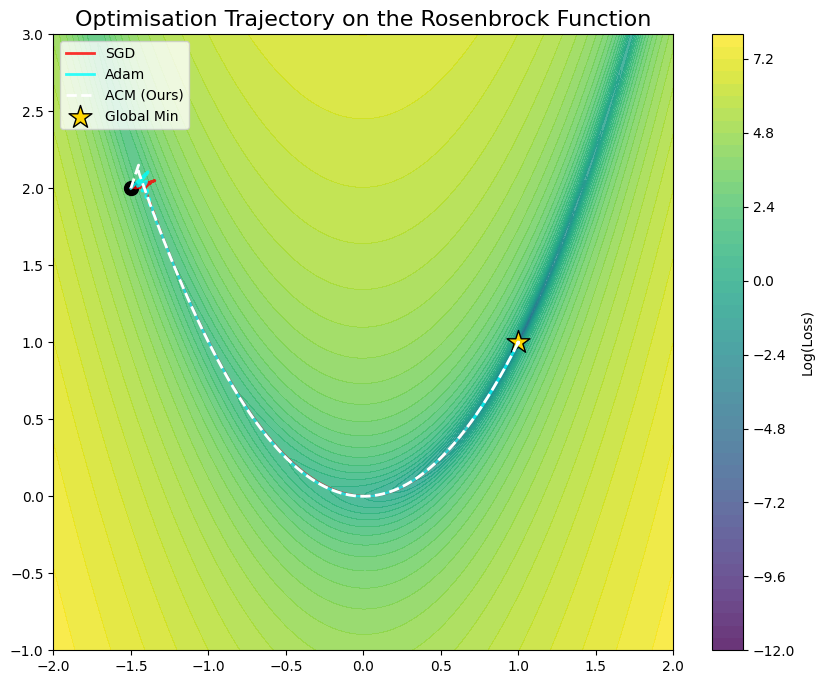

In [ ]:
start_point = [-1.5, 2.0]
iterations = 2500

traj_sgd  = get_trajectory(torch.optim.SGD, start_point, iterations, lr=0.001)
traj_adam = get_trajectory(torch.optim.Adam, start_point, iterations, lr=0.05)
# ACM uses lr=0.1 because the G^-1 tensor rigorously controls the step size
traj_acm  = get_trajectory(ACM, start_point, iterations, lr=0.1, kappa=5.0)

x_grid = np.linspace(-2.0, 2.0, 400)
y_grid = np.linspace(-1.0, 3.0, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z = (1.0 - X)**2 + 100.0 * (Y - X**2)**2

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, np.log(Z), levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(label='Log(Loss)')

plt.plot(traj_sgd[:, 0], traj_sgd[:, 1], color='red', label='SGD', linewidth=2, alpha=0.8)
plt.plot(traj_adam[:, 0], traj_adam[:, 1], color='cyan', label='Adam', linewidth=2, alpha=0.8)
plt.plot(traj_acm[:, 0], traj_acm[:, 1], color='white', label='ACM (Ours)', linewidth=2, linestyle='--')

plt.scatter(*start_point, color='black', marker='o', s=100)
plt.scatter(1, 1, color='gold', marker='*', s=300, edgecolor='black', label='Global Min')

plt.xlim([-2.0, 2.0])
plt.ylim([-1.0, 3.0])
plt.title('Optimisation Trajectory on the Rosenbrock Function', fontsize=16)
plt.legend(loc='upper left')
plt.savefig('rosenbrock.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

# **FashionMNIST 40% Noise Test**

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Corrupt 40% of labels
print("Preparing noisy dataset...")
noise_level = 0.4
num_noisy = int(noise_level * len(train_set))
noisy_indices = random.sample(range(len(train_set)), num_noisy)
for idx in noisy_indices:
    train_set.targets[idx] = random.randint(0, 9)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()

print("\nTraining with Adam...")
model_adam = SimpleCNN().to(device)
opt_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
_, _, _, hist_adam = train_and_evaluate(model_adam, train_loader, test_loader, criterion, opt_adam, epochs=30, patience=30)

print("\nTraining with ACM...")
model_acm = SimpleCNN().to(device)
opt_acm = ACM(model_acm.parameters(), lr=0.01, kappa=1.0)
_, _, _, hist_acm = train_and_evaluate(model_acm, train_loader, test_loader, criterion, opt_acm, epochs=30, patience=30)

Preparing noisy dataset...

Training with Adam...
Epoch 01: Train Loss: 1.6916, Val Acc: 84.12%
Epoch 02: Train Loss: 1.6091, Val Acc: 86.83%
Epoch 03: Train Loss: 1.5818, Val Acc: 87.89%
Epoch 04: Train Loss: 1.5622, Val Acc: 87.39%
Epoch 05: Train Loss: 1.5441, Val Acc: 88.64%
Epoch 06: Train Loss: 1.5254, Val Acc: 88.91%
Epoch 07: Train Loss: 1.5055, Val Acc: 89.13%
Epoch 08: Train Loss: 1.4866, Val Acc: 88.41%
Epoch 09: Train Loss: 1.4628, Val Acc: 89.07%
Epoch 10: Train Loss: 1.4372, Val Acc: 88.73%
Epoch 11: Train Loss: 1.4107, Val Acc: 87.74%
Epoch 12: Train Loss: 1.3813, Val Acc: 87.51%
Epoch 13: Train Loss: 1.3481, Val Acc: 86.61%
Epoch 14: Train Loss: 1.3173, Val Acc: 85.90%
Epoch 15: Train Loss: 1.2848, Val Acc: 85.91%
Epoch 16: Train Loss: 1.2498, Val Acc: 83.23%
Epoch 17: Train Loss: 1.2160, Val Acc: 83.10%
Epoch 18: Train Loss: 1.1832, Val Acc: 83.25%
Epoch 19: Train Loss: 1.1480, Val Acc: 81.14%
Epoch 20: Train Loss: 1.1156, Val Acc: 78.86%
Epoch 21: Train Loss: 1.0847, 

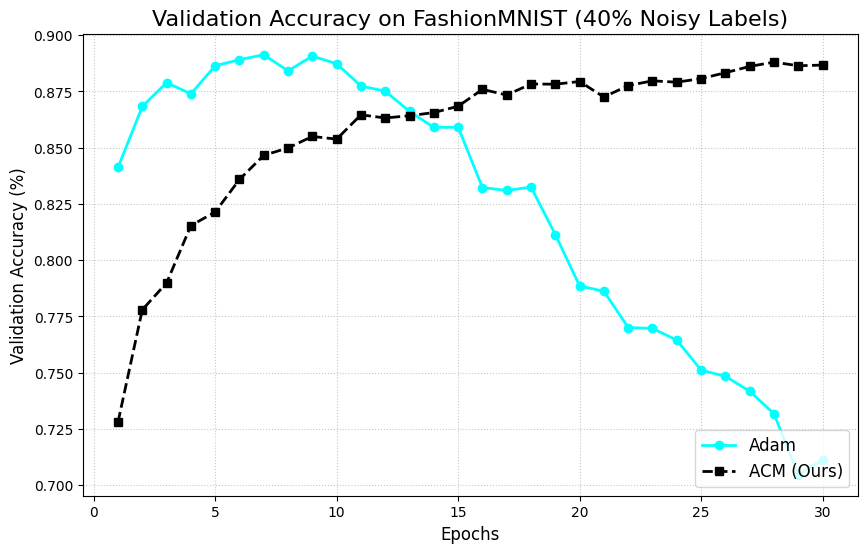

In [ ]:
# Plotting the results for the paper
plt.figure(figsize=(10, 6))
# range(1, 31) It was range(1, 16) before
plt.plot(range(1, 31), hist_adam['val_acc'], label='Adam', color='cyan', linewidth=2, marker='o')
plt.plot(range(1, 31), hist_acm['val_acc'], label='ACM (Ours)', color='black', linewidth=2, linestyle='--', marker='s')

plt.title('Validation Accuracy on FashionMNIST (40% Noisy Labels)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('fashionmnist.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

# **Cora Citation Network GCN Test**

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCN, self).__init__()
        # Standard 2-layer GCN
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [ ]:
# Training Loop for Node Classification
def train_gcn(optimizer_class, data, num_features, num_classes, epochs=200, **opt_kwargs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GCN(num_features, num_classes).to(device)
    data = data.to(device)
    optimizer = optimizer_class(model.parameters(), **opt_kwargs)

    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        # GCNs calculate loss only on the specific training nodes
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Validation Phase
        model.eval()
        with torch.no_grad():
            pred = model(data).argmax(dim=1)
            correct = (pred[data.val_mask] == data.y[data.val_mask]).sum()
            acc = int(correct) / int(data.val_mask.sum())
            val_accuracies.append(acc * 100)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch: {epoch+1:03d}, Loss: {loss:.4f}, Val Acc: {val_accuracies[-1]:.2f}%')

    return val_accuracies

In [ ]:
print("Downloading Cora Dataset...")
cora_dataset = Planetoid(root='/tmp/Cora', name='Cora')
cora_data = cora_dataset[0]

print("=== Training GCN ===\n")
print("Training with Adam...")
cora_adam = train_gcn(torch.optim.Adam, cora_data, cora_dataset.num_node_features, cora_dataset.num_classes, lr=0.01)
print("\nTraining with ACM...")
cora_acm = train_gcn(ACM, cora_data, cora_dataset.num_node_features, cora_dataset.num_classes, lr=0.1, kappa=2.0)

=== Training GCN ===

Training with Adam...
Epoch: 020, Loss: 0.2916, Val Acc: 77.60%
Epoch: 040, Loss: 0.0572, Val Acc: 77.80%
Epoch: 060, Loss: 0.0263, Val Acc: 77.20%
Epoch: 080, Loss: 0.0110, Val Acc: 77.60%
Epoch: 100, Loss: 0.0199, Val Acc: 77.00%
Epoch: 120, Loss: 0.0143, Val Acc: 77.00%
Epoch: 140, Loss: 0.0066, Val Acc: 76.00%
Epoch: 160, Loss: 0.0030, Val Acc: 76.60%
Epoch: 180, Loss: 0.0127, Val Acc: 78.00%
Epoch: 200, Loss: 0.0110, Val Acc: 75.80%

Training with ACM...
Epoch: 020, Loss: 1.8705, Val Acc: 24.00%
Epoch: 040, Loss: 1.7571, Val Acc: 32.20%
Epoch: 060, Loss: 1.6141, Val Acc: 51.00%
Epoch: 080, Loss: 1.4605, Val Acc: 62.60%
Epoch: 100, Loss: 1.2911, Val Acc: 69.40%
Epoch: 120, Loss: 1.1128, Val Acc: 73.00%
Epoch: 140, Loss: 0.9916, Val Acc: 74.80%
Epoch: 160, Loss: 0.8490, Val Acc: 75.60%
Epoch: 180, Loss: 0.7860, Val Acc: 76.20%
Epoch: 200, Loss: 0.7012, Val Acc: 77.20%


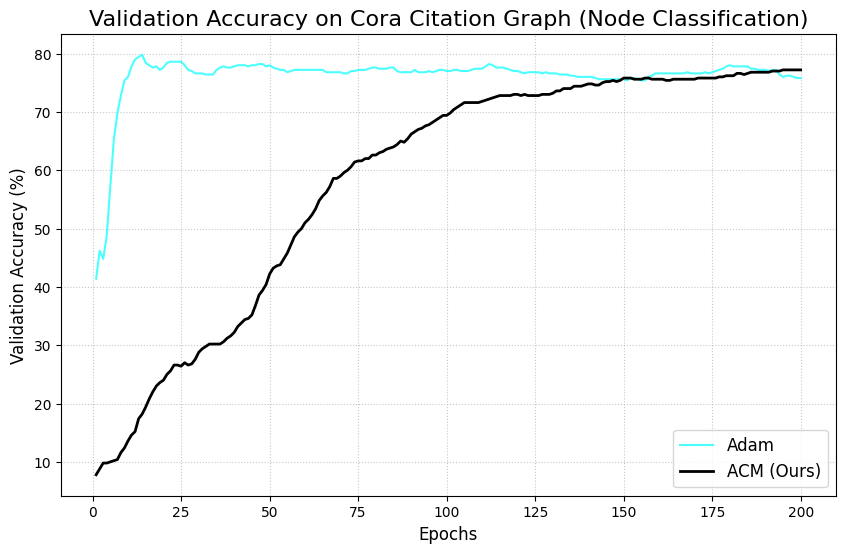

In [ ]:
# Plotting the Results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 201), cora_adam, label='Adam', color='cyan', alpha=0.7)
plt.plot(range(1, 201), cora_acm, label='ACM (Ours)', color='black', linewidth=2)

plt.title('Validation Accuracy on Cora Citation Graph (Node Classification)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('cora.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

# **Cassava Dataset Setup**

In [ ]:
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
if not os.path.exists('raw_kaggle_data'):
    print("Downloading Cassava dataset...")
    os.system("kaggle competitions download -c cassava-leaf-disease-classification")
    os.system("unzip -q cassava-leaf-disease-classification.zip -d raw_kaggle_data")

class CassavaDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self): return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.dataframe.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')
        label = int(self.dataframe.iloc[idx, 1])
        if self.transform: image = self.transform(image)
        return image, label

df = pd.read_csv('raw_kaggle_data/train.csv')
train_df, val_df = torch.utils.data.random_split(df, [int(len(df)*0.8), len(df) - int(len(df)*0.8)])
train_df, val_df = df.iloc[train_df.indices], df.iloc[val_df.indices]

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = CassavaDataset(train_df, 'raw_kaggle_data/train_images', transform_train)
val_dataset = CassavaDataset(val_df, 'raw_kaggle_data/train_images', transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
print("Cassava Data Ready.")

Cassava Data Ready.


# **Data Class Exploration and Training on Cassava Dataset**


--- Sample Images ---


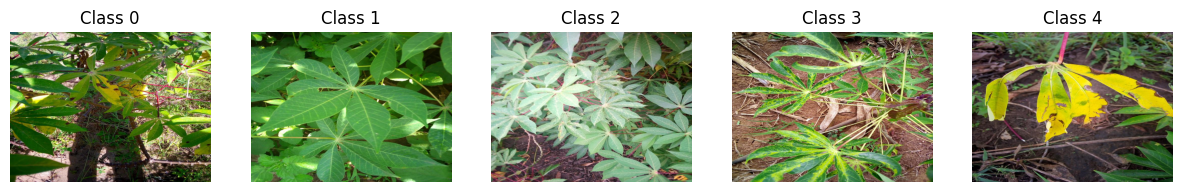

In [ ]:
# IMAGE EXPLORATION: Sample Images using the dataframe and raw image folder
print("\n--- Sample Images ---")
image_folder = 'raw_kaggle_data/train_images'
plt.figure(figsize=(15, 5))

# Get one sample image for each class (0-4)
for i in range(5):
    # Find the first image ID corresponding to this class label
    img_id = df[df['label'] == i]['image_id'].values[0]
    img_path = os.path.join(image_folder, img_id)
    img = Image.open(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Class {i}")
    plt.axis('off')

plt.show()

In [ ]:
# Ensure GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def get_resnet_model(num_classes=5):
    # Load pre-trained ResNet18
    model = models.resnet18(weights='IMAGENET1K_V1')

    # Freeze early layers to speed up training (optional, but recommended for low compute)
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully connected layer for our 5 Cassava classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

model_acm = get_resnet_model(num_classes=5)

Using device: cuda


In [ ]:
# Use the custom CassavaDataset class defined in cell above
# instead of ImageFolder to handle the CSV-based label mapping.

train_dataset = CassavaDataset(train_df, 'raw_kaggle_data/train_images', transform=transform_train)
val_dataset = CassavaDataset(val_df, 'raw_kaggle_data/train_images', transform=transform_val)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"DataLoaders initialised using CassavaDataset.")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

DataLoaders initialised using CassavaDataset.
Training samples: 17117
Validation samples: 4280


In [ ]:
def train_model_v2(model, criterion, optimizer, train_loader, val_loader, scheduler=None, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    epoch_times = []

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 10)

        if torch.cuda.is_available():
            starter.record()

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

        if torch.cuda.is_available():
            ender.record()
            torch.cuda.synchronize()
            curr_time = starter.elapsed_time(ender) / 1000
            epoch_times.append(curr_time)

    avg_time = sum(epoch_times) / len(epoch_times) if epoch_times else 0
    peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0

    print(f'\n--- Compute Metrics ---')
    print(f'Average Epoch Time: {avg_time:.2f} seconds')
    print(f'Peak GPU Memory: {peak_mem:.2f} MB')

    return model, history

# Define the missing variables
criterion = nn.CrossEntropyLoss()
optimizer_acm = ACM(model_acm.parameters(), lr=0.005, kappa=1.0)
scheduler_acm = torch.optim.lr_scheduler.StepLR(optimizer_acm, step_size=5, gamma=0.5)

print("Training ResNet18 with Tuned ACM Optimiser...")
model_acm, history_acm = train_model_v2(model_acm, criterion, optimizer_acm, train_loader, val_loader, scheduler=scheduler_acm, epochs=10)

Training ResNet18 with Tuned ACM Optimiser...
Epoch 1/10
----------
Train Loss: 0.9329 Acc: 0.6584
Val Loss: 0.8109 Acc: 0.6937
Epoch 2/10
----------
Train Loss: 0.8132 Acc: 0.7000
Val Loss: 0.7658 Acc: 0.7185
Epoch 3/10
----------
Train Loss: 0.7830 Acc: 0.7132
Val Loss: 0.7521 Acc: 0.7231
Epoch 4/10
----------
Train Loss: 0.7695 Acc: 0.7162
Val Loss: 0.7370 Acc: 0.7262
Epoch 5/10
----------
Train Loss: 0.7612 Acc: 0.7203
Val Loss: 0.7257 Acc: 0.7325
Epoch 6/10
----------
Train Loss: 0.7428 Acc: 0.7298
Val Loss: 0.7211 Acc: 0.7364
Epoch 7/10
----------
Train Loss: 0.7456 Acc: 0.7259
Val Loss: 0.7245 Acc: 0.7348
Epoch 8/10
----------
Train Loss: 0.7471 Acc: 0.7249
Val Loss: 0.7202 Acc: 0.7341
Epoch 9/10
----------
Train Loss: 0.7382 Acc: 0.7287
Val Loss: 0.7226 Acc: 0.7334
Epoch 10/10
----------
Train Loss: 0.7348 Acc: 0.7304
Val Loss: 0.7190 Acc: 0.7388

--- Compute Metrics ---
Average Epoch Time: 82.13 seconds
Peak GPU Memory: 295.74 MB



--- ACM Classification Report ---
                              precision    recall  f1-score   support

    Cassava Bacterial Blight       0.48      0.41      0.44       201
Cassava Brown Streak Disease       0.51      0.49      0.50       428
        Cassava Green Mottle       0.60      0.32      0.42       512
      Cassava Mosaic Disease       0.83      0.93      0.88      2643
                     Healthy       0.53      0.50      0.52       496

                    accuracy                           0.74      4280
                   macro avg       0.59      0.53      0.55      4280
                weighted avg       0.72      0.74      0.72      4280



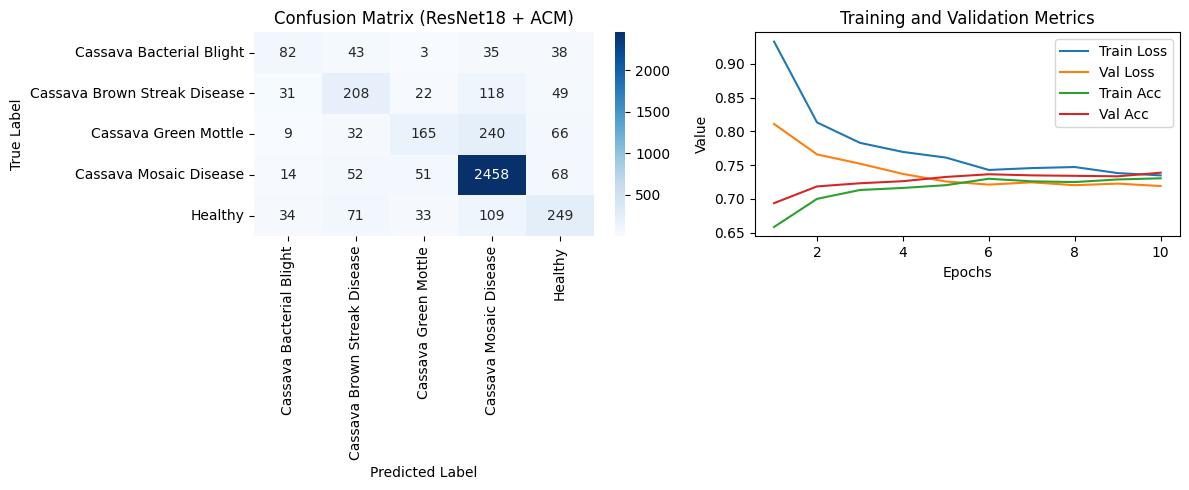

In [ ]:
def evaluate_and_plot(model, dataloader, history, class_names, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- {model_name.upper()} Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix (ResNet18 + {model_name.upper()})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # Plot Training/Validation Curves
    plt.subplot(1, 2, 2)
    epochs = range(1, len(history['train_loss']) + 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Training and Validation Metrics')
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{model_name}_cm.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Class names for the Cassava Dataset
cassava_classes = ['Cassava Bacterial Blight', 'Cassava Brown Streak Disease',
                   'Cassava Green Mottle', 'Cassava Mosaic Disease', 'Healthy']

# Use this method to evaluate models trained with train_model_v2
evaluate_and_plot(model_acm, val_loader, history_acm, cassava_classes, 'acm')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def get_resnet_model(num_classes=5):
    # Load pre-trained ResNet18
    model = models.resnet18(weights='IMAGENET1K_V1')

    # Freeze early layers to speed up training (optional, but recommended for low compute)
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully connected layer for our 5 Cassava classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

model_acm = get_resnet_model(num_classes=5)

Using device: cuda


In [ ]:
# Initialise a fresh baseline ResNet18 to ensure a fair test
print("Initialising baseline ResNet18 with Adam optimiser...")
model_adam = get_resnet_model(num_classes=5)

# Initialise standard Adam optimiser
optimizer_adam = torch.optim.Adam(model_adam.fc.parameters(), lr=0.001)

# Train the baseline model (using the correct function name train_model_v2)
print("Training ResNet18 with standard Adam...")
model_adam, history_adam = train_model_v2(
    model_adam,
    criterion,
    optimizer_adam,
    train_loader,
    val_loader,
    epochs=10
)

Initialising baseline ResNet18 with Adam optimiser...
Training ResNet18 with standard Adam...
Epoch 1/10
----------
Train Loss: 0.8893 Acc: 0.6769
Val Loss: 0.7510 Acc: 0.7210
Epoch 2/10
----------
Train Loss: 0.7876 Acc: 0.7112
Val Loss: 0.7410 Acc: 0.7243
Epoch 3/10
----------
Train Loss: 0.7666 Acc: 0.7162
Val Loss: 0.7325 Acc: 0.7280
Epoch 4/10
----------
Train Loss: 0.7643 Acc: 0.7173
Val Loss: 0.7214 Acc: 0.7355
Epoch 5/10
----------
Train Loss: 0.7552 Acc: 0.7233
Val Loss: 0.7385 Acc: 0.7259
Epoch 6/10
----------
Train Loss: 0.7520 Acc: 0.7262
Val Loss: 0.7351 Acc: 0.7308
Epoch 7/10
----------
Train Loss: 0.7511 Acc: 0.7266
Val Loss: 0.7321 Acc: 0.7325
Epoch 8/10
----------
Train Loss: 0.7524 Acc: 0.7236
Val Loss: 0.7225 Acc: 0.7336
Epoch 9/10
----------
Train Loss: 0.7439 Acc: 0.7296
Val Loss: 0.7193 Acc: 0.7379
Epoch 10/10
----------
Train Loss: 0.7429 Acc: 0.7253
Val Loss: 0.7253 Acc: 0.7383

--- Compute Metrics ---
Average Epoch Time: 81.16 seconds
Peak GPU Memory: 382.36 MB

Generating benchmark comparison plot...


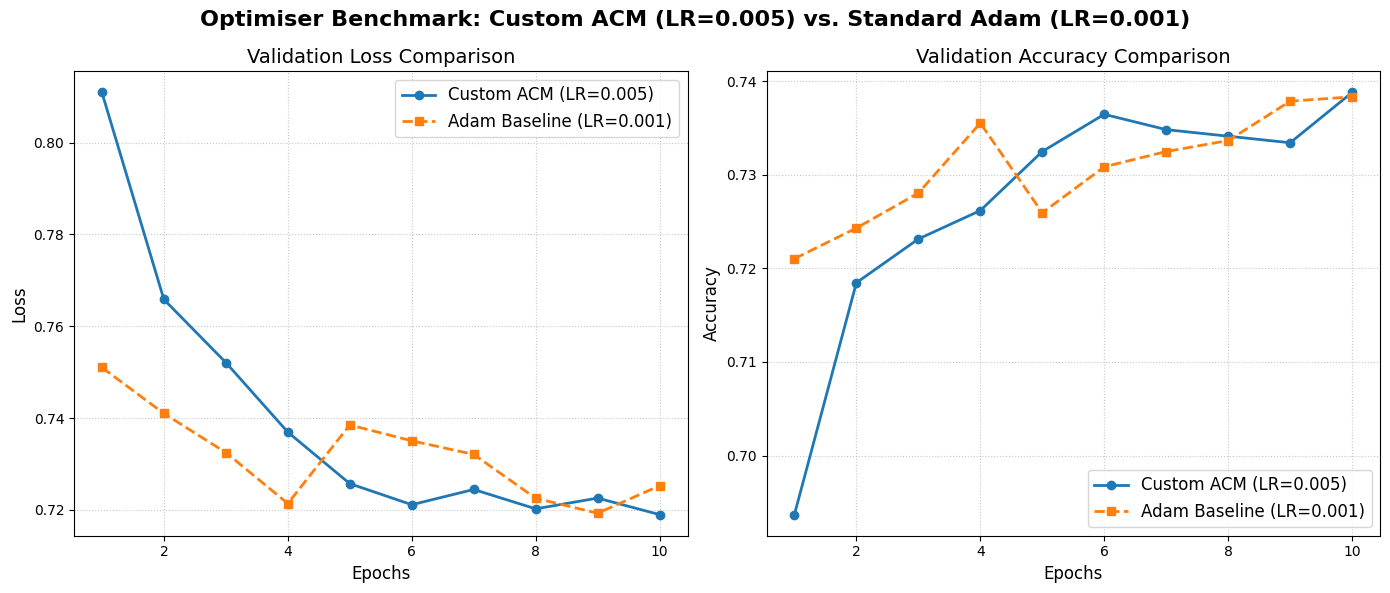

In [ ]:
def plot_optimiser_comparison(history_1, label_1, history_2, label_2):
    epochs = range(1, len(history_1['train_loss']) + 1)

    plt.figure(figsize=(14, 6))

    # Subplot 1: Validation Loss Comparison
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_1['val_loss'], label=f'{label_1}', linestyle='-', marker='o', linewidth=2)
    plt.plot(epochs, history_2['val_loss'], label=f'{label_2}', linestyle='--', marker='s', linewidth=2)
    plt.title('Validation Loss Comparison', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    # Subplot 2: Validation Accuracy Comparison
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_1['val_acc'], label=f'{label_1}', linestyle='-', marker='o', linewidth=2)
    plt.plot(epochs, history_2['val_acc'], label=f'{label_2}', linestyle='--', marker='s', linewidth=2)
    plt.title('Validation Accuracy Comparison', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.suptitle('Optimiser Benchmark: Custom ACM (LR=0.005) vs. Standard Adam (LR=0.001)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('optimiser_benchmark.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

print("Generating benchmark comparison plot...")
plot_optimiser_comparison(history_acm, 'Custom ACM (LR=0.005)', history_adam, 'Adam Baseline (LR=0.001)')

Evaluating ResNet18 trained with Adam...

--- ADAM Classification Report ---
                              precision    recall  f1-score   support

    Cassava Bacterial Blight       0.55      0.36      0.44       201
Cassava Brown Streak Disease       0.57      0.39      0.47       428
        Cassava Green Mottle       0.66      0.28      0.39       512
      Cassava Mosaic Disease       0.83      0.93      0.88      2643
                     Healthy       0.48      0.64      0.55       496

                    accuracy                           0.74      4280
                   macro avg       0.62      0.52      0.54      4280
                weighted avg       0.73      0.74      0.72      4280



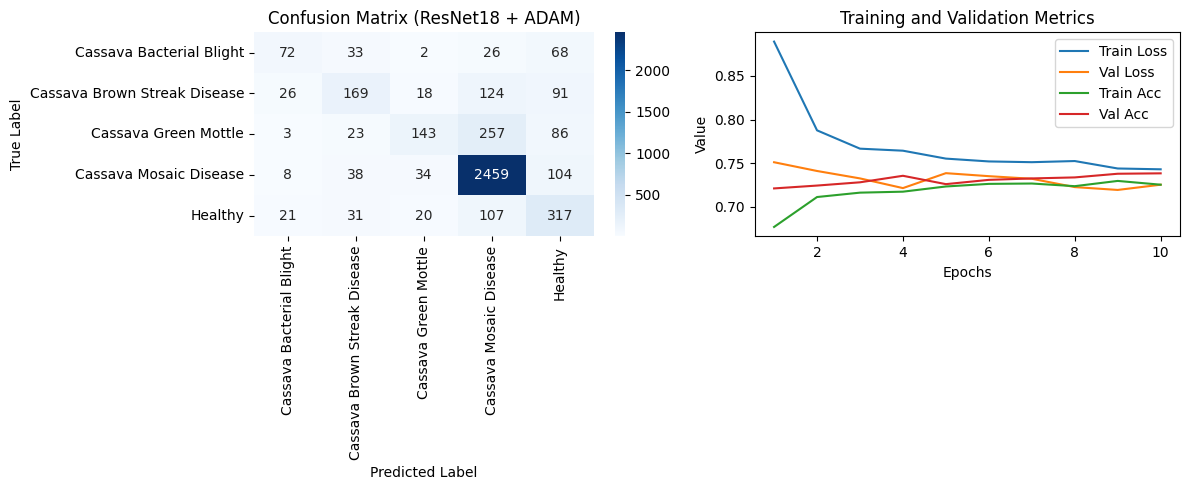

In [ ]:
# Evaluate the Adam baseline model using the existing evaluation function
# The function 'evaluate_and_plot' and 'cassava_classes' are already defined in the ACM evaluation cell.
print("Evaluating ResNet18 trained with Adam...")
evaluate_and_plot(model_adam, val_loader, history_adam, cassava_classes, 'adam')

# **Phase 1 - Hyperparameter Fairness Search**

In [ ]:
optimizers_to_test = {
    'Adam': torch.optim.Adam,
    'AdamW': torch.optim.AdamW,
    'RMSprop': torch.optim.RMSprop,
    'ACM': ACM
}

learning_rates = [0.001, 0.005, 0.01]
best_lrs = {}

print("--- STARTING PHASE 1: HYPERPARAMETER SEARCH (Seed 42) ---")
set_seed(42)

for opt_name, opt_class in optimizers_to_test.items():
    print(f"\nEvaluating: {opt_name}")
    best_acc = 0.0
    for lr in learning_rates:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, 5)
        model = model.to(device)

        if opt_name == 'ACM': opt = opt_class(model.parameters(), lr=lr, kappa=1.0)
        else: opt = opt_class(model.parameters(), lr=lr)

        criterion = nn.CrossEntropyLoss()
        print(f"  Testing LR = {lr}...", end="\n")
        val_acc, _, _, _ = train_and_evaluate(model, train_loader, val_loader, criterion, opt, epochs=5, patience=5)
        print(f" Peak Val Acc: {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_lrs[opt_name] = lr

print("\n--- OPTIMAL LEARNING RATES FOUND ---")
print(best_lrs)

--- STARTING PHASE 1: HYPERPARAMETER SEARCH (Seed 42) ---

Evaluating: Adam
  Testing LR = 0.001...
Epoch 01: Train Loss: 0.7811, Val Acc: 59.72%
Epoch 02: Train Loss: 0.6394, Val Acc: 73.08%
Epoch 03: Train Loss: 0.5761, Val Acc: 79.07%
Epoch 04: Train Loss: 0.5376, Val Acc: 79.21%
Epoch 05: Train Loss: 0.4943, Val Acc: 78.32%
 Peak Val Acc: 79.21%
  Testing LR = 0.005...
Epoch 01: Train Loss: 1.1523, Val Acc: 62.22%
Epoch 02: Train Loss: 0.9612, Val Acc: 64.79%
Epoch 03: Train Loss: 0.8674, Val Acc: 69.16%
Epoch 04: Train Loss: 0.8292, Val Acc: 61.92%
Epoch 05: Train Loss: 0.7976, Val Acc: 69.42%
 Peak Val Acc: 69.42%
  Testing LR = 0.01...
Epoch 01: Train Loss: 1.1635, Val Acc: 64.49%
Epoch 02: Train Loss: 1.0009, Val Acc: 62.43%
Epoch 03: Train Loss: 0.9245, Val Acc: 65.12%
Epoch 04: Train Loss: 0.8649, Val Acc: 68.62%
Epoch 05: Train Loss: 0.8201, Val Acc: 69.65%
 Peak Val Acc: 69.65%

Evaluating: AdamW
  Testing LR = 0.001...
Epoch 01: Train Loss: 0.7865, Val Acc: 76.61%
Epoch 02

# **Phase 2 - Statistical Validation (Multiple Seeds)**

In [ ]:
seeds = [42, 100, 2026]
final_results = []

print("\n--- STARTING PHASE 2: MULTI-SEED TESTING ---")
for opt_name, opt_class in optimizers_to_test.items():
    best_lr = best_lrs[opt_name]
    print(f"\n--- Running {opt_name} at optimal LR={best_lr} ---")

    acc_runs, time_runs, mem_runs = [], [], []
    for seed in seeds:
        set_seed(seed)
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, 5)
        model = model.to(device)

        if opt_name == 'ACM': opt = opt_class(model.parameters(), lr=best_lr, kappa=1.0)
        else: opt = opt_class(model.parameters(), lr=best_lr)

        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
        criterion = nn.CrossEntropyLoss()

        print(f"  Training Seed {seed}...", end="")
        val_acc, avg_time, peak_mem, _ = train_and_evaluate(model, train_loader, val_loader, criterion, opt, scheduler, epochs=10)
        print(f" Acc: {val_acc*100:.2f}%")

        acc_runs.append(val_acc * 100)
        time_runs.append(avg_time)
        mem_runs.append(peak_mem)

    final_results.append({
        'Optimiser': opt_name,
        'Accuracy (%)': f"{np.mean(acc_runs):.2f} ± {np.std(acc_runs):.2f}",
        'Time/Epoch (s)': f"{np.mean(time_runs):.2f}",
        'Peak Mem (MB)': f"{np.mean(mem_runs):.2f}"
    })

df_results = pd.DataFrame(final_results)
display(df_results)


--- STARTING PHASE 2: MULTI-SEED TESTING ---

--- Running Adam at optimal LR=0.001 ---
  Training Seed 42...Epoch 01: Train Loss: 0.7811, Val Acc: 59.72%
Epoch 02: Train Loss: 0.6394, Val Acc: 73.08%
Epoch 03: Train Loss: 0.5761, Val Acc: 79.07%
Epoch 04: Train Loss: 0.5376, Val Acc: 79.21%
Epoch 05: Train Loss: 0.4943, Val Acc: 78.32%
Epoch 06: Train Loss: 0.3877, Val Acc: 82.03%
Epoch 07: Train Loss: 0.3365, Val Acc: 81.99%
Epoch 08: Train Loss: 0.2923, Val Acc: 74.63%
Epoch 09: Train Loss: 0.2439, Val Acc: 80.19%
 Acc: 82.03%
  Training Seed 100...Epoch 01: Train Loss: 0.7913, Val Acc: 46.73%
Epoch 02: Train Loss: 0.6399, Val Acc: 78.08%
Epoch 03: Train Loss: 0.5821, Val Acc: 78.90%
Epoch 04: Train Loss: 0.5360, Val Acc: 76.89%
Epoch 05: Train Loss: 0.5033, Val Acc: 52.01%
Epoch 06: Train Loss: 0.4059, Val Acc: 82.85%
Epoch 07: Train Loss: 0.3466, Val Acc: 83.60%
Epoch 08: Train Loss: 0.3015, Val Acc: 81.92%
Epoch 09: Train Loss: 0.2461, Val Acc: 82.06%
Epoch 10: Train Loss: 0.2080

,Optimiser,Accuracy (%),Time/Epoch (s),Peak Mem (MB)
0,Adam,82.76 ± 0.64,65.83,1065.33
1,AdamW,82.72 ± 0.23,65.88,1065.59
2,RMSprop,81.35 ± 0.30,65.90,1021.71
3,ACM,82.62 ± 0.19,66.98,1065.59


# **Phase 3 - Ablation Study on Kappa**


--- STARTING PHASE 3: ABLATION STUDY (Kappa) ---
Testing ACM with kappa = 0.1...

<>:24: SyntaxWarning: invalid escape sequence '\k'
<>:24: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_131234/1483793630.py:24: SyntaxWarning: invalid escape sequence '\k'
  plt.title("Ablation Study: Impact of Manifold Sensitivity ($\kappa$)", fontsize=14)


Epoch 01: Train Loss: 0.7776, Val Acc: 78.15%
Epoch 02: Train Loss: 0.5621, Val Acc: 80.58%
Epoch 03: Train Loss: 0.4815, Val Acc: 81.45%
Epoch 04: Train Loss: 0.4198, Val Acc: 82.13%
Epoch 05: Train Loss: 0.3656, Val Acc: 82.22%
Epoch 06: Train Loss: 0.3103, Val Acc: 81.82%
Epoch 07: Train Loss: 0.2574, Val Acc: 81.85%
Epoch 08: Train Loss: 0.2073, Val Acc: 82.03%
 Acc: 82.22%
Testing ACM with kappa = 1.0...Epoch 01: Train Loss: 0.7794, Val Acc: 78.55%
Epoch 02: Train Loss: 0.5717, Val Acc: 80.96%
Epoch 03: Train Loss: 0.4884, Val Acc: 81.87%
Epoch 04: Train Loss: 0.4271, Val Acc: 82.45%
Epoch 05: Train Loss: 0.3707, Val Acc: 82.85%
Epoch 06: Train Loss: 0.3185, Val Acc: 82.97%
Epoch 07: Train Loss: 0.2662, Val Acc: 82.45%
Epoch 08: Train Loss: 0.2152, Val Acc: 81.07%
 Acc: 82.97%
Testing ACM with kappa = 5.0...Epoch 01: Train Loss: 0.7846, Val Acc: 78.18%
Epoch 02: Train Loss: 0.5682, Val Acc: 80.61%
Epoch 03: Train Loss: 0.4948, Val Acc: 81.33%
Epoch 04: Train Loss: 0.4303, Val Acc:

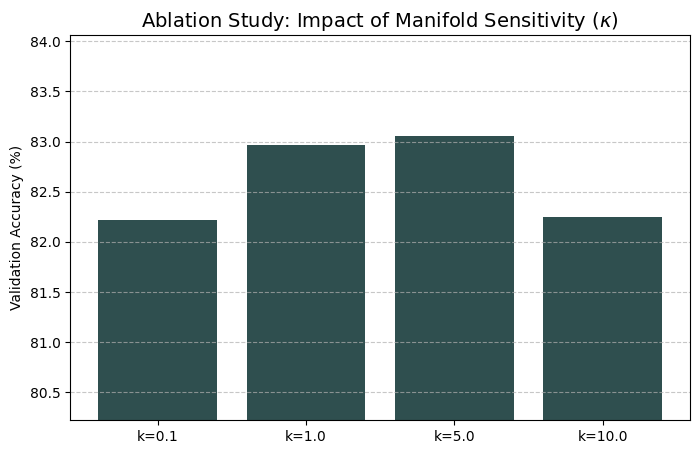

In [ ]:
print("\n--- STARTING PHASE 3: ABLATION STUDY (Kappa) ---")
kappas = [0.1, 1.0, 5.0, 10.0]
ablation_results = {}

set_seed(42)
acm_optimal_lr = best_lrs['ACM']

for k in kappas:
    print(f"Testing ACM with kappa = {k}...", end="")
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 5)
    model = model.to(device)

    optimizer = ACM(model.parameters(), lr=acm_optimal_lr, kappa=k)
    criterion = nn.CrossEntropyLoss()

    val_acc, _, _, _ = train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs=8)
    ablation_results[f'k={k}'] = val_acc * 100
    print(f" Acc: {val_acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(ablation_results.keys(), ablation_results.values(), color='darkslategray')
plt.ylim(min(ablation_results.values()) - 2, max(ablation_results.values()) + 1)
plt.title("Ablation Study: Impact of Manifold Sensitivity ($\kappa$)", fontsize=14)
plt.ylabel("Validation Accuracy (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('ablation_kappa.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()